# **Goal-Oriented Agents for Real-Time Task Automation in Elderly Care**

---

**DESCRIPTION:**

[To be Added]

# Adding Necessary Imports

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
!ls /content/drive/MyDrive/NHANES/

BIOPRO_G.xpt  BIOPRO_H.xpt  BMX_G.xpt  BMX_H.xpt  DEMO_G.xpt  DEMO_H.xpt


In [66]:
# Load the XPT files for both cycles
bioprog = pd.read_sas('/content/drive/MyDrive/NHANES/BIOPRO_G.xpt', format='xport', encoding='utf-8')
demog = pd.read_sas('/content/drive/MyDrive/NHANES/DEMO_G.xpt', format='xport', encoding='utf-8')
bmxg = pd.read_sas('/content/drive/MyDrive/NHANES/BMX_G.xpt', format='xport', encoding='utf-8')

bioproh = pd.read_sas('/content/drive/MyDrive/NHANES/BIOPRO_H.xpt', format='xport', encoding='utf-8')
demoh = pd.read_sas('/content/drive/MyDrive/NHANES/DEMO_H.xpt', format='xport', encoding='utf-8')
bmxh = pd.read_sas('/content/drive/MyDrive/NHANES/BMX_H.xpt', format='xport', encoding='utf-8')

# Merge each cycle on SEQN then combine cycles
df_g = bioprog.merge(demog[['SEQN', 'RIDAGEYR', 'RIAGENDR']], on='SEQN', how='inner')
df_g = df_g.merge(bmxg[['SEQN', 'BMXWT', 'BMXBMI']], on='SEQN', how='inner')
df_g['cycle'] = '2011-2012'

df_h = bioproh.merge(demoh[['SEQN', 'RIDAGEYR', 'RIAGENDR']], on='SEQN', how='inner')
df_h = df_h.merge(bmxh[['SEQN', 'BMXWT', 'BMXBMI']], on='SEQN', how='inner')
df_h['cycle'] = '2013-2014'

# Combine both cycles
df = pd.concat([df_g, df_h], ignore_index=True)

In [67]:
print(f"Total combined records (all ages): {len(df)}")

Total combined records (all ages): 13528


# Filter Geriatric Group (Age >= 65)

In [68]:
# Filter geriatric group (age >= 65)
df = df[df['RIDAGEYR'] >= 65].copy()

In [69]:
df.head()

,SEQN,LBXSAL,LBDSALSI,LBXSATSI,LBXSASSI,LBXSAPSI,LBXSBU,LBDSBUSI,LBXSCA,LBDSCASI,...,LBXSOSSI,LBXSGB,LBDSGBSI,LBXSTR,LBDSTRSI,RIDAGEYR,RIAGENDR,BMXWT,BMXBMI,cycle
8,62174.0,3.1,31.0,30.0,42.0,120.0,9.0,3.21,8.7,2.175,...,278.0,3.4,34.0,89.0,1.005,80.0,1.0,95.8,33.9,2011-2012
11,62178.0,4.2,42.0,13.0,28.0,35.0,16.0,5.71,9.0,2.250,...,284.0,2.5,25.0,105.0,1.185,80.0,1.0,85.9,28.5,2011-2012
19,62191.0,3.7,37.0,13.0,16.0,105.0,13.0,4.64,9.1,2.275,...,279.0,3.6,36.0,67.0,0.756,70.0,1.0,NaN,NaN,2011-2012
32,62215.0,3.7,37.0,22.0,27.0,63.0,23.0,8.21,9.1,2.275,...,287.0,3.1,31.0,73.0,0.824,65.0,2.0,60.2,26.7,2011-2012
33,62217.0,3.8,38.0,22.0,27.0,84.0,13.0,4.64,9.3,2.325,...,278.0,3.1,31.0,104.0,1.174,77.0,2.0,69.8,30.6,2011-2012


# Exploring the Data

In [70]:
df.shape

(2431, 43)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2431 entries, 8 to 13524
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      2431 non-null   float64
 1   LBXSAL    2252 non-null   float64
 2   LBDSALSI  2252 non-null   float64
 3   LBXSATSI  2250 non-null   float64
 4   LBXSASSI  2249 non-null   float64
 5   LBXSAPSI  2251 non-null   float64
 6   LBXSBU    2251 non-null   float64
 7   LBDSBUSI  2251 non-null   float64
 8   LBXSCA    2246 non-null   float64
 9   LBDSCASI  2246 non-null   float64
 10  LBXSCK    2251 non-null   float64
 11  LBXSCH    2251 non-null   float64
 12  LBDSCHSI  2251 non-null   float64
 13  LBXSC3SI  2251 non-null   float64
 14  LBXSCR    2252 non-null   float64
 15  LBDSCRSI  2252 non-null   float64
 16  LBXSGTSI  2251 non-null   float64
 17  LBXSGL    2252 non-null   float64
 18  LBDSGLSI  2252 non-null   float64
 19  LBXSIR    2245 non-null   float64
 20  LBDSIRSI  2245 non-null   float64


In [72]:
relevant_columns = [
    'SEQN',
    'RIDAGEYR',
    'RIAGENDR',
    'BMXWT',
    'BMXBMI',
    'LBXSNASI',
    'LBXSKSI',
    'LBXSCLSI',
    'LBXSBU',
    'LBXSCR',
    'LBXSGL',
    'LBXSAL',
    'LBXSOSSI'
]

df_selected = df[relevant_columns].copy()

df_selected.rename(columns={
    'SEQN': 'ID',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Gender',
    'BMXWT': 'Weight',
    'BMXBMI': 'BMI',
    'LBXSNASI': 'Sodium',
    'LBXSKSI': 'Potassium',
    'LBXSCLSI': 'Chloride',
    'LBXSBU': 'BUN',
    'LBXSCR': 'Creatinine',
    'LBXSGL': 'Glucose',
    'LBXSAL': 'Albumin',
    'LBXSOSSI': 'Osmolality',
    'hydration_status': 'HydrationStatus'
}, inplace=True)

df_selected.head(15)


,ID,Age,Gender,Weight,BMI,Sodium,Potassium,Chloride,BUN,Creatinine,Glucose,Albumin,Osmolality
8,62174.0,80.0,1.0,95.8,33.9,139.0,3.9,109.0,9.0,0.87,132.0,3.1,278.0
11,62178.0,80.0,1.0,85.9,28.5,142.0,3.8,107.0,16.0,1.01,97.0,4.2,284.0
19,62191.0,70.0,1.0,NaN,NaN,140.0,3.8,104.0,13.0,0.80,88.0,3.7,279.0
32,62215.0,65.0,2.0,60.2,26.7,140.0,4.2,107.0,23.0,0.73,160.0,3.7,287.0
33,62217.0,77.0,2.0,69.8,30.6,137.0,4.7,102.0,13.0,0.92,175.0,3.8,278.0
41,62226.0,80.0,1.0,73.1,28.4,138.0,3.5,101.0,16.0,1.07,104.0,4.1,277.0
45,62230.0,75.0,1.0,84.8,29.7,138.0,4.5,102.0,24.0,1.89,97.0,4.4,280.0
55,62248.0,65.0,1.0,71.0,26.6,139.0,4.2,104.0,9.0,1.09,97.0,4.7,276.0
61,62255.0,65.0,1.0,71.0,27.1,138.0,3.9,101.0,11.0,1.03,125.0,4.2,277.0
62,62256.0,80.0,1.0,77.8,26.0,138.0,3.8,101.0,19.0,1.06,104.0,4.1,278.0


In [73]:
df_selected.shape

(2431, 13)

In [74]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2431 entries, 8 to 13524
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          2431 non-null   float64
 1   Age         2431 non-null   float64
 2   Gender      2431 non-null   float64
 3   Weight      2386 non-null   float64
 4   BMI         2368 non-null   float64
 5   Sodium      2251 non-null   float64
 6   Potassium   2250 non-null   float64
 7   Chloride    2251 non-null   float64
 8   BUN         2251 non-null   float64
 9   Creatinine  2252 non-null   float64
 10  Glucose     2252 non-null   float64
 11  Albumin     2252 non-null   float64
 12  Osmolality  2251 non-null   float64
dtypes: float64(13)
memory usage: 265.9 KB


In [75]:
df_selected.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2431.0,73130.116002,6529.640934,62174.0,67454.50,73930.00,78985.00,83724.00
Age,2431.0,73.368161,5.375049,65.0,68.50,73.00,80.00,80.00
Gender,2431.0,1.517071,0.499811,1.0,1.00,2.00,2.00,2.00
Weight,2386.0,77.019237,18.302656,29.1,64.20,75.30,87.80,162.10
BMI,2368.0,28.484882,5.913648,13.4,24.30,27.65,31.70,65.10
Sodium,2251.0,139.622390,2.602480,127.0,138.00,140.00,141.00,148.00
Potassium,2250.0,4.089644,0.413150,2.3,3.80,4.10,4.30,5.80
Chloride,2251.0,103.621057,3.284696,88.0,102.00,104.00,106.00,119.00
BUN,2251.0,17.273212,8.045895,4.0,12.00,16.00,20.00,95.00
Creatinine,2252.0,1.066576,0.682560,0.4,0.79,0.95,1.17,17.41


In [76]:
df_selected.isnull().sum()

,0
ID,0
Age,0
Gender,0
Weight,45
BMI,63
Sodium,180
Potassium,181
Chloride,180
BUN,180
Creatinine,179


In [77]:
df_selected = df_selected.dropna()
df_selected.shape

(2199, 13)

In [78]:
df_selected.isnull().sum()

,0
ID,0
Age,0
Gender,0
Weight,0
BMI,0
Sodium,0
Potassium,0
Chloride,0
BUN,0
Creatinine,0


# Classifying Dehydration into different levels

In [79]:
# Calculating BUN:Cr ratio
def calculate_bun_cr_ratio(bun, creatinine):
    if creatinine == 0:
        return 0
    return bun / creatinine

# For classifying Moderate and Severe cases
def severity_score(na, bun_cr):
    score = 0
    if na >= 150:
        score += 2
    elif na >= 145:
        score += 1

    if bun_cr >= 30:
        score += 2
    elif bun_cr >= 20:
        score += 1

    return score

# Generate Labels
def label_hydration(row):
    osm = row['Osmolality']
    if osm < 275:
        return 'Hyperhydrated'
    elif osm < 296:
        return 'Euhydrated'
    elif osm < 300:
        return 'Mild/Impending'
    else:
        bun_cr = calculate_bun_cr_ratio(row['BUN'], row['Creatinine'])
        # Use Na and BUN/Cr in severity_score function to
        # classify data into Moderate and Severe labels
        score = severity_score(row['Sodium'], bun_cr)
        if score >= 3:
            return 'Severe'
        else:
            return 'Moderate'

df_selected['HydrationStatus'] = df_selected.apply(label_hydration, axis=1)

In [80]:
print("Class distribution BEFORE adding synthetic Severe cases:")
print(df_selected['HydrationStatus'].value_counts())

Class distribution BEFORE adding synthetic Severe cases:
HydrationStatus
Euhydrated        1962
Hyperhydrated      215
Mild/Impending      11
Moderate            11
Name: count, dtype: int64


# Adding Synthetic Data to Train Model on Severe Risk Cases

In [81]:
np.random.seed(42)
n = 50

synthetic_severe = pd.DataFrame({
    'ID':                  [999000 + i for i in range(n)],  # dummy IDs
    'Age':                 np.random.uniform(70, 90, n),
    'Gender':              np.random.choice([1.0, 2.0], n),
    'Weight':              np.random.uniform(45, 75, n),
    'BMI':                 np.random.uniform(18, 28, n),
    'Sodium':              np.random.uniform(155, 165, n),   # severe hypernatremia >155
    'Potassium':           np.random.uniform(3.5, 5.5, n),
    'Chloride':            np.random.uniform(108, 118, n),
    'BUN':                 np.random.uniform(40, 60, n),     # high BUN
    'Creatinine':          np.random.uniform(1.2, 2.0, n),   # elevated Cr
    'Glucose':             np.random.uniform(90, 140, n),
    'Albumin':             np.random.uniform(3.0, 4.5, n),
    'Osmolality':          np.random.uniform(310, 330, n),   # osm > 310 = severe
    'HydrationStatus':     'Severe',
})

# Append to df_elderly
df_selected = pd.concat([df_selected, synthetic_severe], ignore_index=True)

In [82]:
print("Class distribution AFTER adding synthetic Severe cases:")
print(df_selected['HydrationStatus'].value_counts())

Class distribution AFTER adding synthetic Severe cases:
HydrationStatus
Euhydrated        1962
Hyperhydrated      215
Severe              50
Mild/Impending      11
Moderate            11
Name: count, dtype: int64


In [83]:
print(df_selected.head())
print(df_selected['HydrationStatus'].value_counts())

        ID   Age  Gender  Weight   BMI  Sodium  Potassium  Chloride   BUN  \
0  62174.0  80.0     1.0    95.8  33.9   139.0        3.9     109.0   9.0   
1  62178.0  80.0     1.0    85.9  28.5   142.0        3.8     107.0  16.0   
2  62215.0  65.0     2.0    60.2  26.7   140.0        4.2     107.0  23.0   
3  62217.0  77.0     2.0    69.8  30.6   137.0        4.7     102.0  13.0   
4  62226.0  80.0     1.0    73.1  28.4   138.0        3.5     101.0  16.0   

   Creatinine  Glucose  Albumin  Osmolality HydrationStatus  
0        0.87    132.0      3.1       278.0      Euhydrated  
1        1.01     97.0      4.2       284.0      Euhydrated  
2        0.73    160.0      3.7       287.0      Euhydrated  
3        0.92    175.0      3.8       278.0      Euhydrated  
4        1.07    104.0      4.1       277.0      Euhydrated  
HydrationStatus
Euhydrated        1962
Hyperhydrated      215
Severe              50
Mild/Impending      11
Moderate            11
Name: count, dtype: int64


In [84]:
print(f"Total elderly records: {len(df_selected)}")

Total elderly records: 2249


# Exploring Labeled Data

In [85]:
df_selected.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2249.0,93862.265451,136672.278018,62174.0,67647.00,74476.00,79417.00,999049.000000
Age,2249.0,73.392585,5.436363,65.0,69.00,73.00,80.00,89.398197
Gender,2249.0,1.513117,0.499939,1.0,1.00,2.00,2.00,2.000000
Weight,2249.0,76.970567,18.327260,29.1,64.10,75.30,87.80,162.100000
BMI,2249.0,28.411524,5.878214,13.4,24.30,27.60,31.60,62.200000
Sodium,2249.0,140.074563,3.967609,127.0,138.00,140.00,141.00,164.367300
Potassium,2249.0,4.102356,0.427906,2.3,3.80,4.10,4.30,5.800000
Chloride,2249.0,103.828779,3.530122,88.0,102.00,104.00,106.00,119.000000
BUN,2249.0,17.896712,9.172814,4.0,12.00,16.00,21.00,95.000000
Creatinine,2249.0,1.076882,0.679416,0.4,0.79,0.96,1.19,17.410000


In [86]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2249 non-null   float64
 1   Age              2249 non-null   float64
 2   Gender           2249 non-null   float64
 3   Weight           2249 non-null   float64
 4   BMI              2249 non-null   float64
 5   Sodium           2249 non-null   float64
 6   Potassium        2249 non-null   float64
 7   Chloride         2249 non-null   float64
 8   BUN              2249 non-null   float64
 9   Creatinine       2249 non-null   float64
 10  Glucose          2249 non-null   float64
 11  Albumin          2249 non-null   float64
 12  Osmolality       2249 non-null   float64
 13  HydrationStatus  2249 non-null   object 
dtypes: float64(13), object(1)
memory usage: 246.1+ KB


In [87]:
df_selected.shape

(2249, 14)

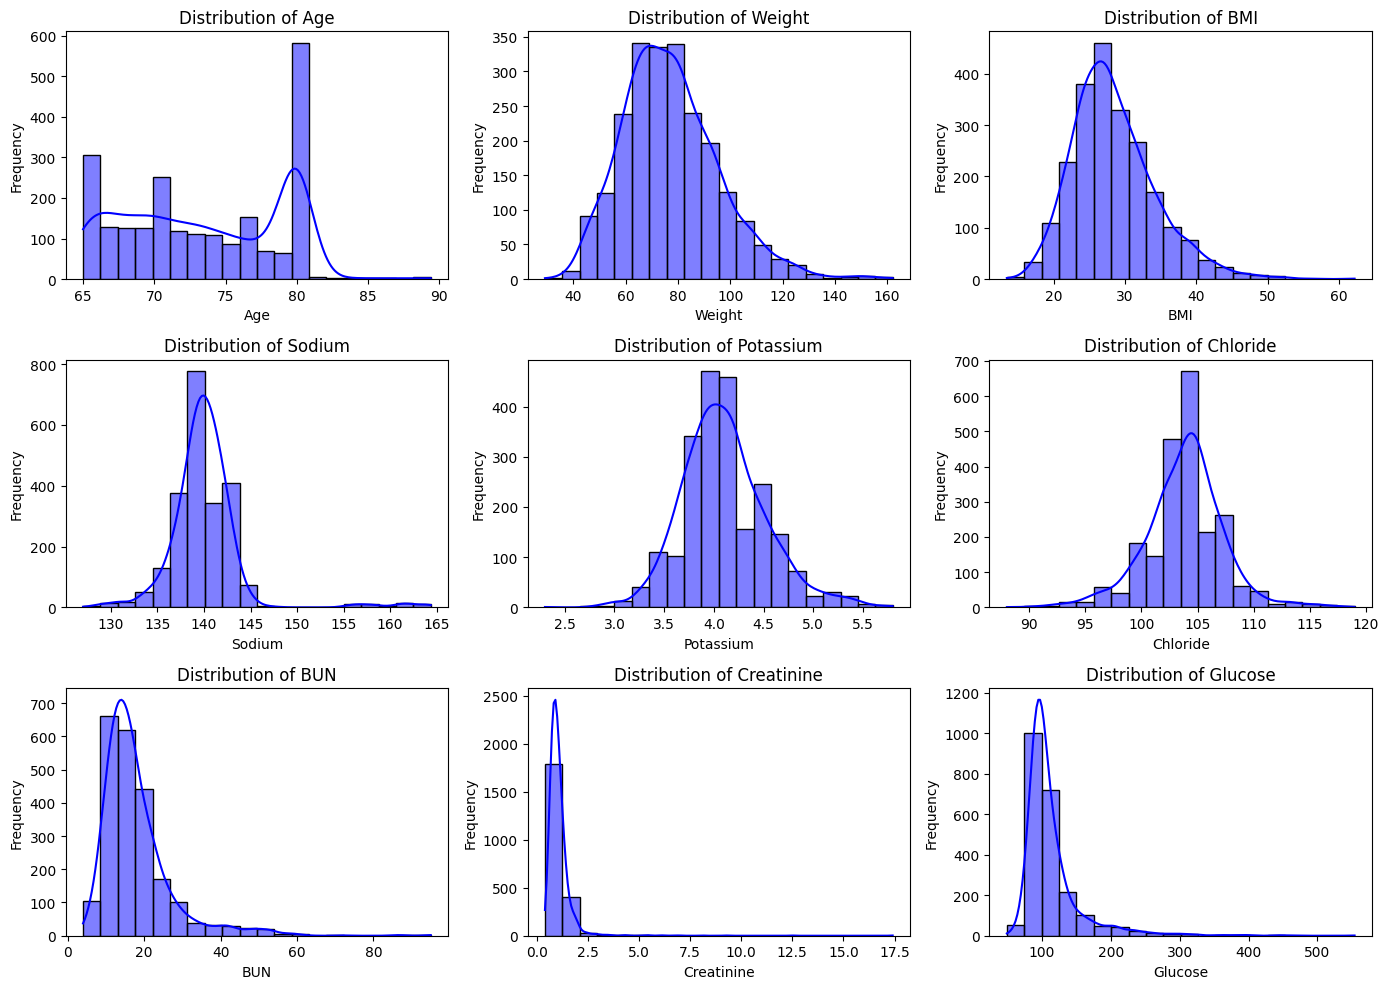

In [88]:
# Features to plot
features_to_plot = ['Age','Weight', 'BMI', 'Sodium', 'Potassium',
                    'Chloride', 'BUN', 'Creatinine', 'Glucose']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_selected[feature], bins=20, color='blue', kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

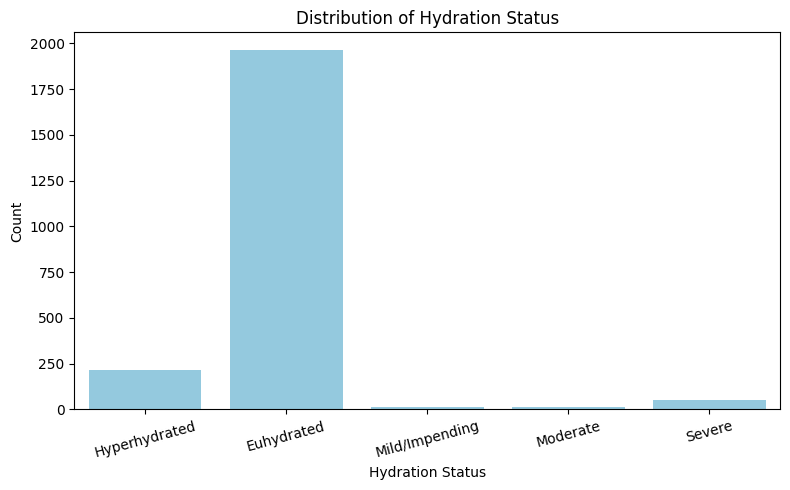

In [89]:
# Distribution of hydration classes
plt.figure(figsize=(8, 5))
sns.countplot(x='HydrationStatus', data=df_selected,
              order=['Hyperhydrated', 'Euhydrated', 'Mild/Impending', 'Moderate', 'Severe'],
              color='skyblue')
plt.title('Distribution of Hydration Status')
plt.xlabel('Hydration Status')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

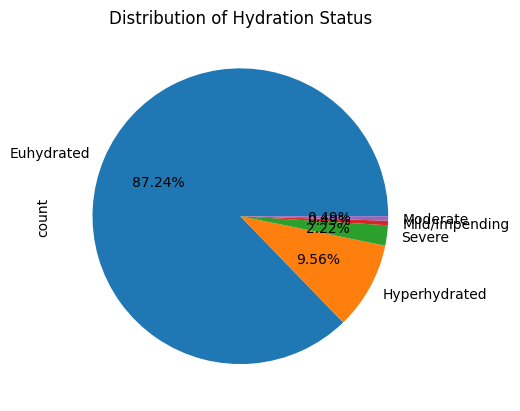

In [90]:
# Pie chart
df_selected['HydrationStatus'].value_counts().plot(kind='pie', autopct='%.2f%%')
plt.title('Distribution of Hydration Status')
plt.show()

# Derive Target Field

In [91]:
# Encode target labels
label_mapping = {
    'Hyperhydrated':  0,
    'Euhydrated':     1,
    'Mild/Impending': 2,
    'Moderate':       3,
    'Severe':         4
}

df_selected['HydrationStatusEncoded'] = df_selected['HydrationStatus'].map(label_mapping)

df_selected.head()

,ID,Age,Gender,Weight,BMI,Sodium,Potassium,Chloride,BUN,Creatinine,Glucose,Albumin,Osmolality,HydrationStatus,HydrationStatusEncoded
0,62174.0,80.0,1.0,95.8,33.9,139.0,3.9,109.0,9.0,0.87,132.0,3.1,278.0,Euhydrated,1
1,62178.0,80.0,1.0,85.9,28.5,142.0,3.8,107.0,16.0,1.01,97.0,4.2,284.0,Euhydrated,1
2,62215.0,65.0,2.0,60.2,26.7,140.0,4.2,107.0,23.0,0.73,160.0,3.7,287.0,Euhydrated,1
3,62217.0,77.0,2.0,69.8,30.6,137.0,4.7,102.0,13.0,0.92,175.0,3.8,278.0,Euhydrated,1
4,62226.0,80.0,1.0,73.1,28.4,138.0,3.5,101.0,16.0,1.07,104.0,4.1,277.0,Euhydrated,1


In [92]:
# Feature columns (Osmolality excluded — it was used for labeling only, not a feature)
feature_cols = ['Sodium', 'Potassium', 'Chloride',
                'BUN', 'Creatinine',
                'Glucose', 'Age', 'Gender', 'Weight', 'BMI']

In [93]:
X = df_selected[feature_cols]
y = df_selected['HydrationStatusEncoded']

In [94]:
X.head()

,Sodium,Potassium,Chloride,BUN,Creatinine,Glucose,Age,Gender,Weight,BMI
0,139.0,3.9,109.0,9.0,0.87,132.0,80.0,1.0,95.8,33.9
1,142.0,3.8,107.0,16.0,1.01,97.0,80.0,1.0,85.9,28.5
2,140.0,4.2,107.0,23.0,0.73,160.0,65.0,2.0,60.2,26.7
3,137.0,4.7,102.0,13.0,0.92,175.0,77.0,2.0,69.8,30.6
4,138.0,3.5,101.0,16.0,1.07,104.0,80.0,1.0,73.1,28.4


In [95]:
X.shape

(2249, 10)

In [96]:
y.head()

,HydrationStatusEncoded
0,1
1,1
2,1
3,1
4,1


In [97]:
y.value_counts()

,count
HydrationStatusEncoded,
1,1962
0,215
4,50
2,11
3,11


# SMOTE

In [98]:
from imblearn.over_sampling import SMOTE

In [99]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [100]:
print("Class distribution before SMOTE:")
print(pd.Series(y).value_counts())

Class distribution before SMOTE:
HydrationStatusEncoded
1    1962
0     215
4      50
2      11
3      11
Name: count, dtype: int64


In [101]:
print("Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

Class distribution after SMOTE:
HydrationStatusEncoded
1    1962
0    1962
2    1962
3    1962
4    1962
Name: count, dtype: int64


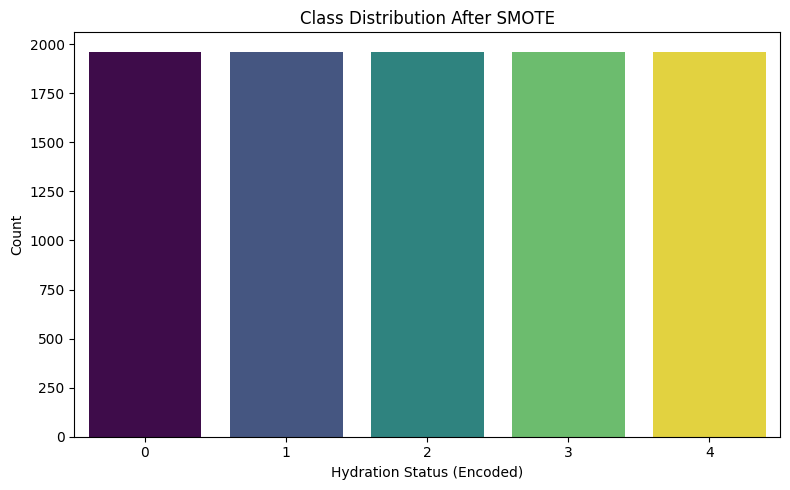

In [102]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, hue=y_resampled, palette='viridis', legend=False)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Hydration Status (Encoded)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Split the Data

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [105]:
X_train.head()

,Sodium,Potassium,Chloride,BUN,Creatinine,Glucose,Age,Gender,Weight,BMI
3945,136.178352,3.753506,104.000000,10.643296,0.812866,105.070112,71.535056,1.821648,69.866300,27.600000
4113,138.000000,4.279692,97.652022,47.144894,3.204655,241.014256,80.000000,2.000000,62.388129,24.556415
1360,139.000000,3.300000,102.000000,16.000000,0.850000,97.000000,65.000000,2.000000,64.500000,26.000000
5653,143.954616,4.111346,105.022692,25.340381,1.599515,193.205777,75.113460,1.022692,98.829655,34.349768
8616,159.858241,5.195047,110.466820,55.046744,1.554188,134.205677,77.739202,1.311816,49.017345,20.140302


In [106]:
X_test.head()

,Sodium,Potassium,Chloride,BUN,Creatinine,Glucose,Age,Gender,Weight,BMI
3114,134.00000,4.279119,97.000000,12.835233,0.763850,131.895596,74.313212,1.895596,99.801632,43.739482
4978,138.97340,4.435107,107.513300,43.430865,2.937182,270.236760,68.297867,1.000000,110.209849,38.975270
1569,139.00000,4.000000,101.000000,31.000000,2.250000,82.000000,65.000000,2.000000,88.900000,33.700000
764,141.00000,4.500000,105.000000,20.000000,1.030000,159.000000,75.000000,1.000000,107.100000,38.700000
7296,146.05904,4.946231,100.016343,95.000000,16.314454,133.829211,67.344229,1.865577,122.177120,47.965312


In [107]:
y_train.head()

,HydrationStatusEncoded
3945,0
4113,2
1360,1
5653,2
8616,4


In [108]:
y_test.head()

,HydrationStatusEncoded
3114,0
4978,2
1569,1
764,1
7296,3


In [109]:
print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (7848, 10)
Test set:     (1962, 10)


# Train the Model

In [110]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [111]:
target_names = ['Hyperhydrated', 'Euhydrated', 'Mild/Impending', 'Moderate', 'Severe']

In [112]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

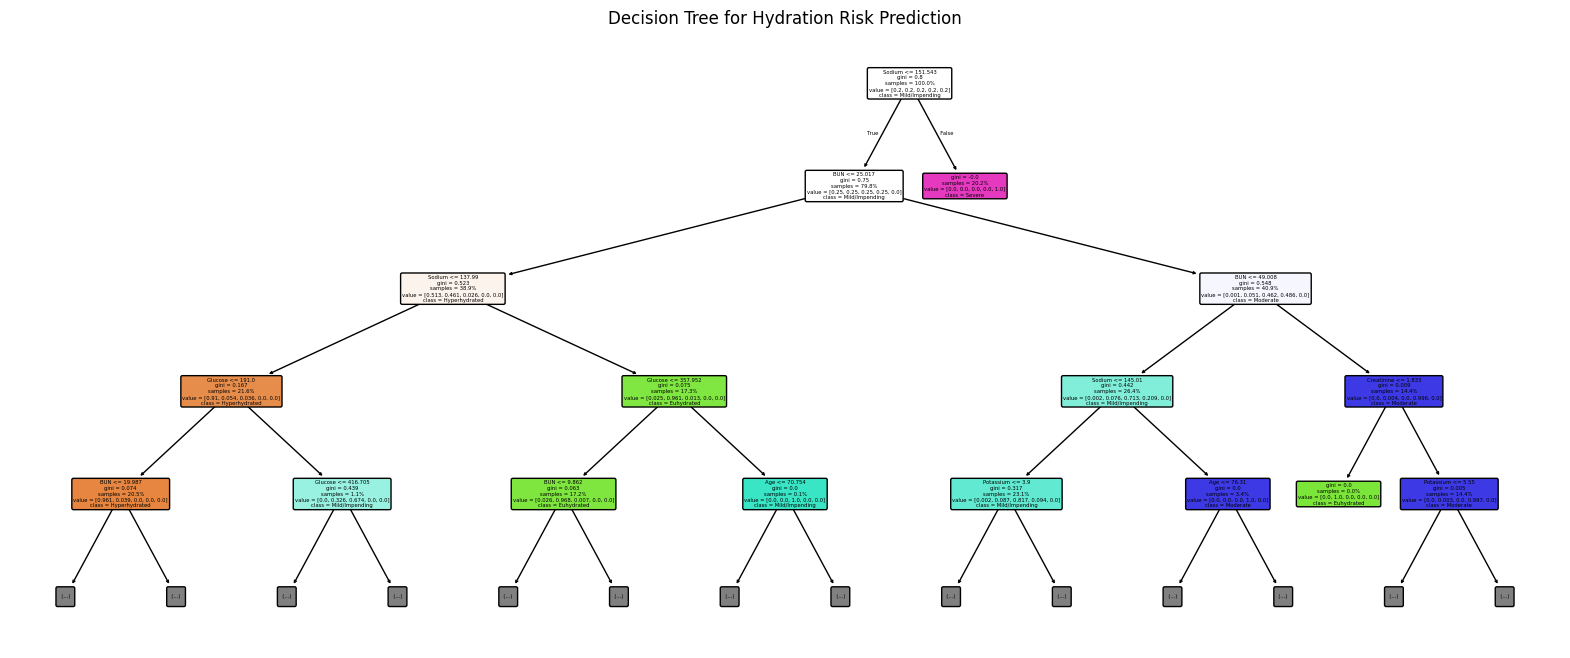

In [113]:
plt.figure(figsize=(20, 8))
plot_tree(dt_model, filled=True, feature_names=feature_cols,
          class_names=target_names, rounded=True, proportion=True, max_depth=4)
plt.title("Decision Tree for Hydration Risk Prediction")
plt.show()

In [114]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

# Evaluate the Model

In [115]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [116]:
dt_pred = dt_model.predict(X_test)

In [117]:
print("Decision Tree\n")
print(f"Accuracy: {accuracy_score(y_test, dt_pred) * 100:.2f}%")
print(classification_report(y_test, dt_pred, target_names=target_names))

Decision Tree

Accuracy: 98.67%
                precision    recall  f1-score   support

 Hyperhydrated       0.97      0.99      0.98       377
    Euhydrated       0.98      0.95      0.97       404
Mild/Impending       0.98      1.00      0.99       406
      Moderate       1.00      1.00      1.00       400
        Severe       1.00      1.00      1.00       375

      accuracy                           0.99      1962
     macro avg       0.99      0.99      0.99      1962
  weighted avg       0.99      0.99      0.99      1962



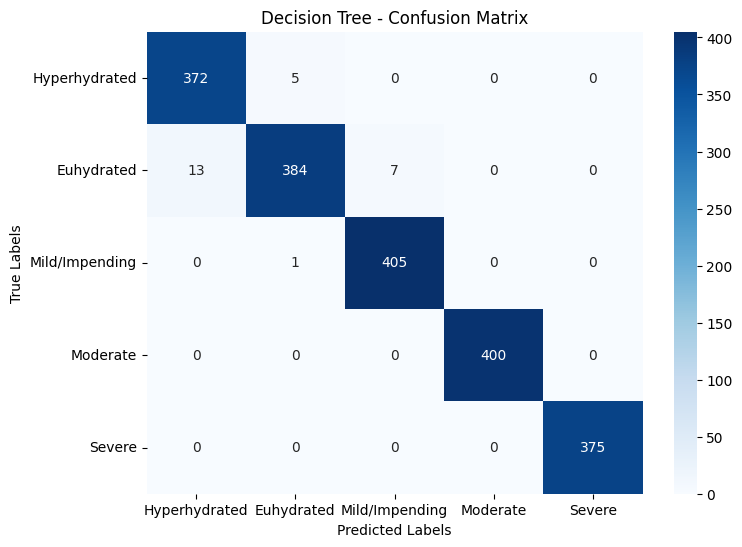

In [118]:
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

In [119]:
rf_pred = rf_model.predict(X_test)

In [120]:
print("Random Forest\n")
print(f"Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print(classification_report(y_test, rf_pred, target_names=target_names))

Random Forest

Accuracy: 99.34%
                precision    recall  f1-score   support

 Hyperhydrated       0.98      0.99      0.99       377
    Euhydrated       0.99      0.98      0.98       404
Mild/Impending       1.00      1.00      1.00       406
      Moderate       1.00      1.00      1.00       400
        Severe       1.00      1.00      1.00       375

      accuracy                           0.99      1962
     macro avg       0.99      0.99      0.99      1962
  weighted avg       0.99      0.99      0.99      1962



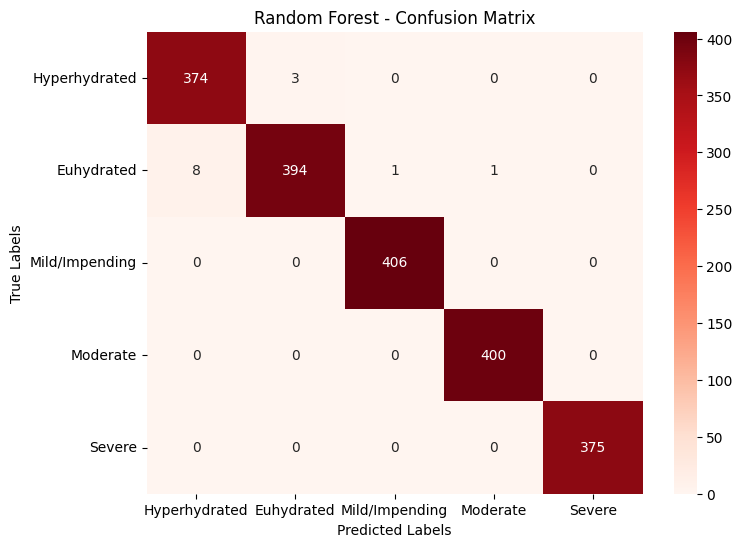

In [121]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Random Forest - Confusion Matrix')
plt.show()

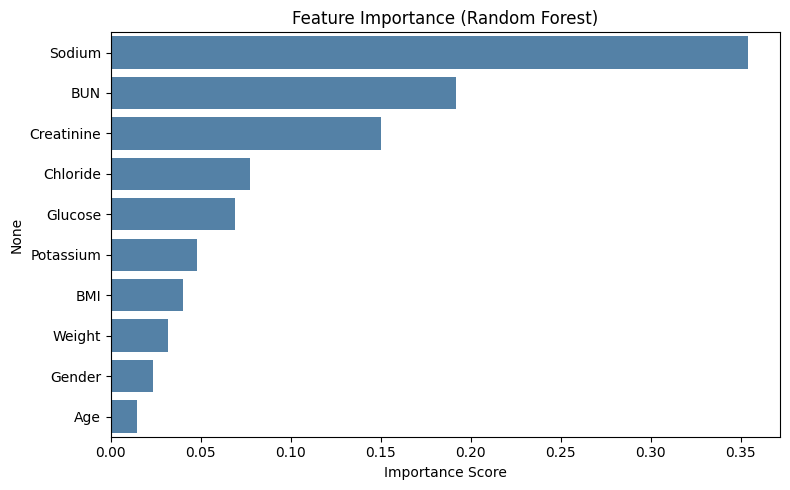

In [122]:
# Feature importance (Random Forest)
feat_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Export the Model

In [126]:
import joblib

In [130]:
joblib.dump(dt_model, 'dehydration_model_dt.pkl')

['dehydration_model_dt.pkl']

In [131]:
joblib.dump(rf_model, 'dehydration_model_rf.pkl')

['dehydration_model_rf.pkl']